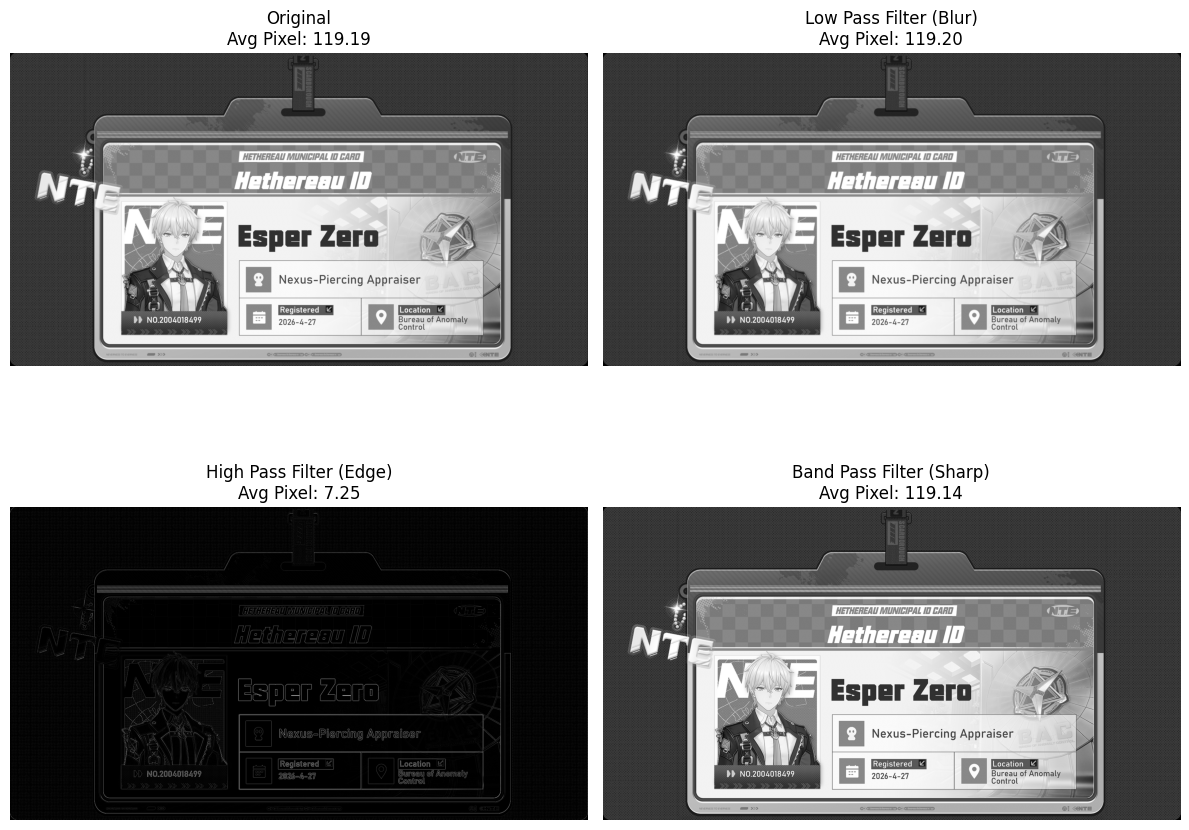

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Baca citra grayscale
img_path = 'NTE_My_Hethereau_ID_Card.png'
img_original = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

if img_original is None:
    print("Gambar tidak ditemukan!")
else:
    # --- Definisi Kernel ---
    # LPF (Averaging)
    kernel_lpf = np.ones((3, 3), np.float32) / 9

    # HPF (Edge Detection)
    kernel_hpf = np.array([[-1, -1, -1],
                           [-1,  8, -1],
                           [-1, -1, -1]])

    # BPF (Sharpening)
    kernel_bpf = np.array([[ 0, -1,  0],
                           [-1,  5, -1],
                           [ 0, -1,  0]])

    # --- Terapkan Konvolusi ---
    img_lpf = cv2.filter2D(img_original, -1, kernel_lpf)
    img_hpf = cv2.filter2D(img_original, -1, kernel_hpf)
    img_bpf = cv2.filter2D(img_original, -1, kernel_bpf)

    # --- Hitung Nilai Piksel Rata-rata ---
    avg_pixels = {
        "Original": np.mean(img_original),
        "LPF": np.mean(img_lpf),
        "HPF": np.mean(img_hpf),
        "BPF": np.mean(img_bpf)
    }

    # 2. Tampilkan Hasil
    titles = ['Original', 'Low Pass Filter (Blur)', 'High Pass Filter (Edge)', 'Band Pass Filter (Sharp)']
    images = [img_original, img_lpf, img_hpf, img_bpf]

    plt.figure(figsize=(12, 10))
    for i in range(4):
        plt.subplot(2, 2, i+1)
        plt.imshow(images[i], cmap='gray')
        plt.title(f"{titles[i]}\nAvg Pixel: {avg_pixels[list(avg_pixels.keys())[i]]:.2f}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()